# 🧹 DATA PREPROCESSING PIPELINE (5 BƯỚC CHUẨN ENGINE)
**Dự án:** Store-Level Sales Forecasting Engine  
**Phụ trách:** Tùng (Data Analyst)  
**Mục tiêu:** Tiền xử lý, gộp dữ liệu, tạo đặc trưng Time-series chống Data Leakage và phân tách 2 tập dữ liệu (`train_sub`, `val_set`).

---

### 📌 Những thay đổi so với bản trước

| # | Thay đổi | Lý do |
|---|---|---|
| 1 | **Bỏ nối `test.csv`** (`pd.concat`) | `test.csv` không có nhãn `Weekly_Sales` → `groupby().sum()` biến nó thành `0.0` giả. Xem giải thích ở BƯỚC 1 |
| 2 | **Bỏ `dropna(Lag_52)`** | Giữ lại 52 tuần đầu để không phí dữ liệu. Cây quyết định xử lý được `NaN` |
| 3 | **Chia 2/3 – 1/3** thay vì mốc cố định | 95 tuần train / 48 tuần val. Val có trọn một mùa lễ cuối năm để chấm |
| 4 | Thêm `Lag_4`, `Lag_12`, `Rolling_Mean_12w`, `Rolling_Std_4w`, `Quarter` | Bắt thêm chu kỳ tháng và quý |
| 5 | Rolling dùng `min_periods=1` | Giảm `NaN` ở đầu chuỗi từ 4–13% xuống ~1% |
| 6 | MarkDown: `fillna(0)` **kèm cờ** `Has_MarkDown_1..5` | Điền 0 mà không mất thông tin "tuần đó có chạy khuyến mãi hay không" |
| 7 | **Xuất ra `data/processed/`** thay vì `data/raw/` | `data/raw/` là dữ liệu gốc bất biến, không được ghi đè |

# KHAI BÁO THƯ VIỆN

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("✅ Đã khai báo thư viện thành công!")

✅ Đã khai báo thư viện thành công!


### BƯỚC 1: Đọc tập Train (`train.csv`)
* **Mục đích:** Nạp dữ liệu lịch sử **có nhãn** để làm nền cho toàn bộ pipeline.

> ⚠️ **Đã bỏ việc nối `test.csv` vào (`pd.concat`).**
>
> `test.csv` **không có cột `Weekly_Sales`** — đó chính là thứ cần dự báo. Khi nối vào rồi `groupby(...).sum()`, pandas coi nhóm toàn `NaN` là **`0.0`**, nên 1.755 dòng của giai đoạn test biến thành *"cửa hàng bán được 0 đồng"* thay vì *"chưa biết"*.
>
> Hệ quả dây chuyền của bản cũ: `train_final` (lọc `notna()`) nuốt luôn giai đoạn test → `val_set` kéo tới **2013-07-26** với 1.755 dòng doanh số 0 giả → `test_final` **rỗng 0 dòng** nhưng vẫn ghi ra file. Tỉ lệ train/val 50/50 khi đó không phải lựa chọn mà là **triệu chứng của bug này**.
>
> Vì `test.csv` không có nhãn nên cũng không chấm điểm được gì trên đó. Bỏ hẳn ra khỏi pipeline là cách gọn nhất — nguyên nhân gốc biến mất luôn.

In [2]:
# ==============================================================================
# BƯỚC 1: ĐỌC TẬP TRAIN
# ==============================================================================

# 1.1 Hàm dò đường dẫn thông minh: Tự tìm nơi thực sự chứa file 'train.csv'
def get_data_dir():
    """Dò ngược cây thư mục tìm nơi chứa train.csv -> chạy được ở máy khác."""
    current_dir = Path.cwd().resolve()

    search_paths = [current_dir / 'data' / 'raw', current_dir / 'data']
    for p in current_dir.parents:
        search_paths.append(p / 'data' / 'raw')
        search_paths.append(p / 'data')

    for path in search_paths:
        if (path / 'train.csv').exists():
            return path.resolve()

    raise FileNotFoundError(
        "❌ Không tìm thấy file 'train.csv'! Hãy kiểm tra xem bạn đã chép các file .csv "
        "vào thư mục 'data/' hoặc 'data/raw/' trong dự án chưa."
    )


# Thư mục dữ liệu GỐC (chỉ đọc) và thư mục dữ liệu ĐÃ XỬ LÝ (ghi ra)
DATA_DIR = get_data_dir()
PROCESSED_DIR = DATA_DIR.parent / 'processed' if DATA_DIR.name == 'raw' else DATA_DIR / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Dữ liệu gốc (chỉ đọc) : {DATA_DIR}")
print(f"📁 Nơi ghi file đã xử lý  : {PROCESSED_DIR}")

# 1.2 Đọc file dữ liệu thô — CHỈ train.csv, không đụng test.csv
train = pd.read_csv(DATA_DIR / 'train.csv')
train['Date'] = pd.to_datetime(train['Date'])

print(f"\n✅ [BƯỚC 1] Đã đọc train.csv: {len(train):,} dòng "
      f"({train['Date'].min():%Y-%m-%d} → {train['Date'].max():%Y-%m-%d}, "
      f"{train['Date'].nunique()} tuần).")
print(f"   Số ô thiếu ở Weekly_Sales: {train['Weekly_Sales'].isna().sum()} "
      f"(phải bằng 0 — mọi dòng đều có nhãn)")

📁 Dữ liệu gốc (chỉ đọc) : D:\my_AI_my_learn\AIO_Conquer_Module3_PorscheClub\data\raw
📁 Nơi ghi file đã xử lý  : D:\my_AI_my_learn\AIO_Conquer_Module3_PorscheClub\data\processed

✅ [BƯỚC 1] Đã đọc train.csv: 421,570 dòng (2010-02-05 → 2012-10-26, 143 tuần).
   Số ô thiếu ở Weekly_Sales: 0 (phải bằng 0 — mọi dòng đều có nhãn)


### BƯỚC 2: GroupBy nén doanh số về cấp Cửa hàng (Store Level)
* **Mục đích:** Tiêu biến hoàn toàn nhiễu từ các Dept nhỏ và tình trạng đứt đoạn dòng thời gian bằng cách cộng dồn doanh số cấp Store.

In [3]:
# --------------------------------------------------------------------------
# BƯỚC 2: GROUPBY NÉN DOANH SỐ VỀ CẤP STORE (45 store × 143 tuần = 6.435 dòng)
# --------------------------------------------------------------------------
# Dùng .agg() thay vì nhét IsHoliday vào khoá groupby:
#   IsHoliday là thuộc tính của Date (mọi store trong cùng 1 tuần đều giống nhau),
#   nên nó chỉ cần "đi ké" chứ không nên làm khoá. Nếu lỡ dữ liệu lệch, để trong
#   khoá sẽ âm thầm tách (Store, Date) thành 2 dòng mà không ai biết.
df_store = train.groupby(['Store', 'Date'], as_index=False).agg(
    Weekly_Sales=('Weekly_Sales', 'sum'),
    IsHoliday=('IsHoliday', 'first'),
)

# --- CỔNG CHẤT LƯỢNG: sai ở đây thì mọi thứ phía sau đều sai ---
assert not df_store.duplicated(['Store', 'Date']).any(), "Có dòng trùng (Store, Date)!"
assert df_store['Weekly_Sales'].isna().sum() == 0, "Có Weekly_Sales bị NaN sau khi gộp!"
assert len(df_store) == df_store['Store'].nunique() * df_store['Date'].nunique(), \
    "Lưới (Store × Date) không đầy — có store thiếu tuần!"

print(f"✅ [BƯỚC 2] Đã nén doanh số về cấp Store. Tổng số dòng: {len(df_store):,} dòng.")
print(f"   = {df_store['Store'].nunique()} cửa hàng × {df_store['Date'].nunique()} tuần")
print(f"   Khoảng thời gian: Từ {df_store['Date'].min():%Y-%m-%d} đến {df_store['Date'].max():%Y-%m-%d}")
print(f"   Số dòng doanh số âm sau khi gộp: {(df_store['Weekly_Sales'] < 0).sum()} "
      f"(cấp Dept có 1.285 dòng âm — gộp lên Store thì triệt tiêu hết)")
df_store.head()

✅ [BƯỚC 2] Đã nén doanh số về cấp Store. Tổng số dòng: 6,435 dòng.
   = 45 cửa hàng × 143 tuần
   Khoảng thời gian: Từ 2010-02-05 đến 2012-10-26
   Số dòng doanh số âm sau khi gộp: 0 (cấp Dept có 1.285 dòng âm — gộp lên Store thì triệt tiêu hết)


,Store,Date,Weekly_Sales,IsHoliday
0,1,2010-02-05,1643690.90,False
1,1,2010-02-12,1641957.44,True
2,1,2010-02-19,1611968.17,False
3,1,2010-02-26,1409727.59,False
4,1,2010-03-05,1554806.68,False


### BƯỚC 3: Merge các bảng ngoại cảnh (`features.csv` & `stores.csv`)
* **Mục đích:** Bổ sung các yếu tố Vĩ mô (`CPI`, `Fuel_Price`, `Unemployment`) và Nội tại Cửa hàng (`Size`, `Type`) trên bảng gọn ~6,000 dòng để tối ưu bộ nhớ RAM.

In [4]:
# ==============================================================================
# BƯỚC 3: MERGE CÁC BẢNG NGOẠI CẢNH (FEATURES.CSV & STORES.CSV)
# ==============================================================================
features = pd.read_csv(DATA_DIR / 'features.csv')
stores = pd.read_csv(DATA_DIR / 'stores.csv')
features['Date'] = pd.to_datetime(features['Date'])

n_before = len(df_store)

# Merge 1-1 trên cấp Store & Date.
# Bỏ IsHoliday khỏi features trước khi ghép: cột này đã có sẵn ở df_store,
# để cả hai bên rồi ghép theo 3 khoá sẽ dễ hụt dòng nếu 2 nguồn lệch nhau.
df_merged = df_store.merge(stores, on='Store', how='left')
df_merged = df_merged.merge(features.drop(columns=['IsHoliday']), on=['Store', 'Date'], how='left')

# Sắp xếp đúng thứ tự thời gian theo từng Store (Bắt buộc để tính Lag chính xác)
df_merged = df_merged.sort_values(by=['Store', 'Date']).reset_index(drop=True)

# --- CỔNG CHẤT LƯỢNG: merge không được làm sinh/mất dòng ---
assert len(df_merged) == n_before, f"Merge làm đổi số dòng: {n_before} → {len(df_merged)}!"
assert df_merged['Size'].isna().sum() == 0, "Có store không ghép được với stores.csv!"
assert df_merged['Temperature'].isna().sum() == 0, "Có (Store, Date) không ghép được với features.csv!"

macro_cols = ['CPI', 'Unemployment', 'Fuel_Price', 'Temperature']
print(f"✅ [BƯỚC 3] Đã merge xong bảng ngoại cảnh. Kích thước DataFrame: {df_merged.shape}")
print("   Số ô thiếu ở nhóm biến vĩ mô (trong phạm vi train):")
for c in macro_cols:
    print(f"     • {c:<14}: {df_merged[c].isna().sum()}")
print("   → Không thiếu ô nào nên KHÔNG cần ffill. (Phần CPI/Unemployment thiếu 585 ô")
print("     nằm trọn ở 13 tuần cuối test.csv — mà test.csv đã bỏ khỏi pipeline.)")

✅ [BƯỚC 3] Đã merge xong bảng ngoại cảnh. Kích thước DataFrame: (6435, 15)
   Số ô thiếu ở nhóm biến vĩ mô (trong phạm vi train):
     • CPI           : 0
     • Unemployment  : 0
     • Fuel_Price    : 0
     • Temperature   : 0
   → Không thiếu ô nào nên KHÔNG cần ffill. (Phần CPI/Unemployment thiếu 585 ô
     nằm trọn ở 13 tuần cuối test.csv — mà test.csv đã bỏ khỏi pipeline.)


### BƯỚC 4: Tạo các biến Time-Series (`Lag` & `Rolling`) chống Data Leakage
* **Mục đích:** Tạo bộ đặc trưng quá khứ bằng `.shift()` để đảm bảo tuyệt đối không lấy dữ liệu tương lai hoặc doanh số của chính tuần đó.

**Bộ đặc trưng mở rộng:**

| Nhóm | Cột | Bắt tín hiệu gì |
|---|---|---|
| Lag | `Lag_1` | Đà tuần trước |
| | `Lag_4` | Cùng kỳ ~1 tháng trước |
| | `Lag_12` | Cùng kỳ ~1 quý trước *(chuẩn xác là 13 tuần = 52/4, dùng 12 cho gọn)* |
| | `Lag_52` | Cùng kỳ năm ngoái — mạnh nhất vì mùa vụ lặp theo năm |
| Rolling | `Rolling_Mean_4w`, `Rolling_Mean_12w` | Mức nền ngắn hạn và trung hạn |
| | `Rolling_Std_4w` | Độ dao động gần đây |
| Lịch | `Year`, `Month`, `Quarter`, `WeekOfYear` | Vị trí trong chu kỳ năm |
| Khuyến mãi | `Has_MarkDown_1..5`, `Markdown_Count`, `Total_MarkDown` | Có chạy chương trình nào không, quy mô bao nhiêu |

**Hai điểm kỹ thuật:**

1. **Rolling dùng `min_periods=1`** — thay vì đòi đủ `window` tuần mới chịu tính, có 1 tuần là tính. Kéo `NaN` ở đầu chuỗi từ 4–13% xuống ~1%. *(Lag thì không có mẹo nào tương tự: `Lag_52` cần doanh số của 52 tuần trước, mà 52 tuần đầu thì dữ liệu đó không tồn tại. Không tạo ra được thông tin không có.)*

2. **MarkDown điền 0 nhưng tạo cờ trước.** `NaN` ở đây nghĩa là *"tuần đó không chạy khuyến mãi"*, khác với *"có chạy nhưng bằng 0đ"*. Tạo `Has_MarkDown_i` **trước khi** `fillna(0)` giữ được đúng sự phân biệt đó — vừa hết `NaN`, vừa không mất thông tin.

In [5]:
# --------------------------------------------------------------------------
# BƯỚC 4: TẠO CÁC BIẾN TIME-SERIES (LAG & ROLLING) TRÊN DF_MERGED
# --------------------------------------------------------------------------
LAGS = [1, 4, 12, 52]           # tuần trước / ~1 tháng / ~1 quý / cùng kỳ năm ngoái
ROLL_WINDOWS = [4, 12]
MARKDOWN_COLS = [f'MarkDown{i}' for i in range(1, 6)]

g = df_merged.groupby('Store')['Weekly_Sales']

# 4.1 Biến Lag Lịch sử — .shift(n) chỉ nhìn về quá khứ, không bao giờ chạm tuần hiện tại
for n in LAGS:
    df_merged[f'Lag_{n}'] = g.shift(n)

# 4.2 Biến Rolling — .shift(1) TRƯỚC rồi mới .rolling() để cửa sổ kết thúc ở t-1
#     min_periods=1: có 1 tuần lịch sử là tính, không đợi đủ cửa sổ
for w in ROLL_WINDOWS:
    df_merged[f'Rolling_Mean_{w}w'] = g.transform(
        lambda x, w=w: x.shift(1).rolling(w, min_periods=1).mean()
    )
df_merged['Rolling_Std_4w'] = g.transform(
    lambda x: x.shift(1).rolling(4, min_periods=2).std()      # std cần ít nhất 2 điểm
)

# 4.3 Trích xuất đặc trưng Thời gian
df_merged['Year'] = df_merged['Date'].dt.year
df_merged['Month'] = df_merged['Date'].dt.month
df_merged['Quarter'] = df_merged['Date'].dt.quarter
df_merged['WeekOfYear'] = df_merged['Date'].dt.isocalendar().week.astype(int)
df_merged['IsHoliday'] = df_merged['IsHoliday'].astype(int)

# 4.4 MarkDown: TẠO CỜ TRƯỚC rồi mới điền 0 (giữ được ý nghĩa "không chạy khuyến mãi")
for i, col in enumerate(MARKDOWN_COLS, start=1):
    df_merged[f'Has_MarkDown_{i}'] = df_merged[col].notna().astype(int)

df_merged['Markdown_Count'] = df_merged[[f'Has_MarkDown_{i}' for i in range(1, 6)]].sum(axis=1)
df_merged[MARKDOWN_COLS] = df_merged[MARKDOWN_COLS].fillna(0)
df_merged['Total_MarkDown'] = df_merged[MARKDOWN_COLS].sum(axis=1)

# --- CỔNG CHẤT LƯỢNG: chỉ nhóm Lag/Rolling được phép còn NaN ---
lag_roll_cols = [f'Lag_{n}' for n in LAGS] + \
                [f'Rolling_Mean_{w}w' for w in ROLL_WINDOWS] + ['Rolling_Std_4w']
other_na = df_merged.drop(columns=lag_roll_cols).isna().sum().sum()
assert other_na == 0, f"Còn {other_na} ô NaN ngoài nhóm Lag/Rolling!"

print("✅ [BƯỚC 4] Đã tạo xong đặc trưng Lag, Rolling, Lịch và MarkDown.")
print(f"   Kích thước DataFrame: {df_merged.shape}\n")
print("   %NaN của nhóm Lag/Rolling (chỉ ở đầu mỗi chuỗi, sẽ giữ nguyên cho cây tự xử):")
for c in lag_roll_cols:
    print(f"     • {c:<18}: {df_merged[c].isna().mean() * 100:5.1f}%")
print(f"\n   Tỷ lệ dòng có ghi nhận khuyến mãi: {(df_merged['Markdown_Count'] > 0).mean() * 100:.1f}%")

✅ [BƯỚC 4] Đã tạo xong đặc trưng Lag, Rolling, Lịch và MarkDown.
   Kích thước DataFrame: (6435, 33)

   %NaN của nhóm Lag/Rolling (chỉ ở đầu mỗi chuỗi, sẽ giữ nguyên cho cây tự xử):
     • Lag_1             :   0.7%
     • Lag_4             :   2.8%
     • Lag_12            :   8.4%
     • Lag_52            :  36.4%
     • Rolling_Mean_4w   :   0.7%
     • Rolling_Mean_12w  :   0.7%
     • Rolling_Std_4w    :   1.4%

   Tỷ lệ dòng có ghi nhận khuyến mãi: 35.7%


### BƯỚC 5: Phân tách 2 tập dữ liệu (`train_sub`, `val_set`)

* **Mục đích:** Cắt theo thời gian thành tập huấn luyện và tập kiểm thử nội bộ, theo tỉ lệ **2/3 – 1/3**.

**Đã bỏ `dropna(Lag_52)`.** Bản cũ xoá 52 tuần đầu mỗi cửa hàng vì `Lag_52` chưa có giá trị — mất tới 2.340 dòng, gần 36% dữ liệu. Không cần thiết: `DecisionTreeRegressor` từ sklearn 1.4 **xử lý `NaN` bằng cách định tuyến** chứ không đòi phải điền số. Tại mỗi nút, cây thử đẩy toàn bộ `NaN` sang nhánh trái, rồi thử sang nhánh phải, và chọn hướng làm giảm sai số nhiều hơn.

**Vì sao mốc cắt rơi vào `2011-12-02`:**

```
143 tuần × 2/3 = 95.33  →  95 tuần train,  còn 48 tuần val   (66.4% / 33.6%)
```

Và mốc này còn một cái lợi lớn:

```
train.csv:  2010-02 ──────────────────────────────────── 2012-10-26
                │                                              │
   mùa lễ:   T11-12/2010          T11-12/2011           (KHÔNG có T11-12/2012
                                        ▲                 vì train.csv dừng 26/10)
                       cắt ở đây ───────┘  2011-12-02

  train  95w  2010-02-05 → 2011-11-25   ← có mùa lễ 2010
  val    48w  2011-12-02 → 2012-10-26   ← có mùa lễ 2011  ✔
```

Toàn bộ dữ liệu chỉ có **2 mùa lễ cuối năm**. Cắt muộn hơn thì cả hai mùa lễ đều rơi vào train, val không còn tháng 11–12 nào để chấm — trong khi metric WMAE nhân trọng số **×5** cho tuần lễ.

In [6]:
# --------------------------------------------------------------------------
# BƯỚC 5: CẮT THÀNH TRAIN_SUB VÀ VAL_SET THEO TỈ LỆ 2/3 - 1/3
# --------------------------------------------------------------------------
TRAIN_RATIO = 2 / 3

weeks = np.sort(df_merged['Date'].unique())
n_train_weeks = int(round(len(weeks) * TRAIN_RATIO))
VAL_SPLIT_DATE = pd.Timestamp(weeks[n_train_weeks])      # tuần ĐẦU TIÊN của val

train_sub = df_merged[df_merged['Date'] < VAL_SPLIT_DATE].copy()
val_set = df_merged[df_merged['Date'] >= VAL_SPLIT_DATE].copy()

# --- CỔNG CHẤT LƯỢNG: không được rò rỉ thời gian, không được mất dòng ---
assert train_sub['Date'].max() < val_set['Date'].min(), "Train và Val chồng lấn thời gian!"
assert len(train_sub) + len(val_set) == len(df_merged), "Cắt xong bị mất dòng!"
assert val_set[lag_roll_cols].isna().sum().sum() == 0, "val_set còn NaN — đánh giá sẽ bị méo!"


def _mo_ta(ten, d):
    return (f"✅ [{ten:<10}] {len(d):>5,} dòng | {d['Date'].min():%Y-%m-%d} → {d['Date'].max():%Y-%m-%d}"
            f" | {d['Date'].nunique():>3} tuần | {d.loc[d['IsHoliday'] == 1, 'Date'].nunique()} tuần lễ")


print("=" * 74)
print("📊 BÁO CÁO KIỂM ĐỊNH TẬP DỮ LIỆU SAU KHI XỬ LÝ (QC CHECK)")
print("=" * 74)
print(f"Tổng cộng    : {len(weeks)} tuần có nhãn → cắt 2/3 tại {VAL_SPLIT_DATE:%Y-%m-%d}")
print(_mo_ta('TRAIN_SUB', train_sub))
print(_mo_ta('VAL_SET', val_set))
print(f"Tỉ lệ        : {len(train_sub) / len(df_merged):.1%} / {len(val_set) / len(df_merged):.1%}")
print("=" * 74)

# Bảng %NaN theo từng tập — chính bảng này lẽ ra đã lộ bug của bản cũ từ đầu
print("\n📌 %NaN CỦA NHÓM LAG/ROLLING THEO TỪNG TẬP")
na_report = pd.DataFrame({
    'train_sub': (train_sub[lag_roll_cols].isna().mean() * 100).round(1),
    'val_set': (val_set[lag_roll_cols].isna().mean() * 100).round(1),
})
print(na_report.to_string())
print("\n→ val_set sạch 0% NaN ở mọi cột: khi chấm điểm không phải bù trừ gì.")
print("→ Lag_52 thiếu ~55% trên train là cái giá của việc giữ lại 52 tuần đầu.")
print("  Cây học một nhánh riêng cho nhóm 'chưa biết cùng kỳ năm ngoái'.")

📊 BÁO CÁO KIỂM ĐỊNH TẬP DỮ LIỆU SAU KHI XỬ LÝ (QC CHECK)
Tổng cộng    : 143 tuần có nhãn → cắt 2/3 tại 2011-12-02
✅ [TRAIN_SUB ] 4,275 dòng | 2010-02-05 → 2011-11-25 |  95 tuần | 7 tuần lễ
✅ [VAL_SET   ] 2,160 dòng | 2011-12-02 → 2012-10-26 |  48 tuần | 3 tuần lễ
Tỉ lệ        : 66.4% / 33.6%

📌 %NaN CỦA NHÓM LAG/ROLLING THEO TỪNG TẬP
                  train_sub  val_set
Lag_1                   1.1      0.0
Lag_4                   4.2      0.0
Lag_12                 12.6      0.0
Lag_52                 54.7      0.0
Rolling_Mean_4w         1.1      0.0
Rolling_Mean_12w        1.1      0.0
Rolling_Std_4w          2.1      0.0

→ val_set sạch 0% NaN ở mọi cột: khi chấm điểm không phải bù trừ gì.
→ Lag_52 thiếu ~55% trên train là cái giá của việc giữ lại 52 tuần đầu.
  Cây học một nhánh riêng cho nhóm 'chưa biết cùng kỳ năm ngoái'.


In [7]:
# --------------------------------------------------------------------------
# BƯỚC 5 (ĐÓNG GÓI): XUẤT DỮ LIỆU SẠCH VÀO data/processed/
# --------------------------------------------------------------------------
# ⚠️ KHÔNG ghi vào data/raw/. Thư mục đó chứa dữ liệu gốc tải từ Kaggle,
#    phải giữ bất biến để mọi người còn dựng lại pipeline từ đầu được.
#    Bản cũ ghi nhầm vào đó vì get_data_dir() dò thấy data/raw trước tiên.
#
# Cũng sửa tên file: bản cũ lưu `train_sub` thành 'train_final.csv' — tên file
# không khớp tên DataFrame, làm cell EDA phía dưới đọc nhầm mà không ai biết.

train_sub.to_csv(PROCESSED_DIR / 'train_sub.csv', index=False)
val_set.to_csv(PROCESSED_DIR / 'val_set.csv', index=False)

print("=" * 74)
print("🎉 [COMPLETED] Đã xuất thành công 2 tệp dữ liệu sạch:")
print(f"📁 Thư mục: {PROCESSED_DIR}")
print(f"   • train_sub.csv : {len(train_sub):>5,} dòng × {train_sub.shape[1]} cột")
print(f"   • val_set.csv   : {len(val_set):>5,} dòng × {val_set.shape[1]} cột")
print("=" * 74)
print(f"\n📁 data/raw/ vẫn nguyên vẹn: {sorted(p.name for p in DATA_DIR.glob('*.csv'))}")

🎉 [COMPLETED] Đã xuất thành công 2 tệp dữ liệu sạch:
📁 Thư mục: D:\my_AI_my_learn\AIO_Conquer_Module3_PorscheClub\data\processed
   • train_sub.csv : 4,275 dòng × 33 cột
   • val_set.csv   : 2,160 dòng × 33 cột

📁 data/raw/ vẫn nguyên vẹn: ['features.csv', 'stores.csv', 'test.csv', 'train.csv']


In [8]:
df1 = pd.read_csv(PROCESSED_DIR / 'val_set.csv')
print(f"val_set.csv: {df1.shape[0]:,} dòng × {df1.shape[1]} cột")
df1.head(10)

val_set.csv: 2,160 dòng × 33 cột


,Store,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Lag_1,Lag_4,Lag_12,Lag_52,Rolling_Mean_4w,Rolling_Mean_12w,Rolling_Std_4w,Year,Month,Quarter,WeekOfYear,Has_MarkDown_1,Has_MarkDown_2,Has_MarkDown_3,Has_MarkDown_4,Has_MarkDown_5,Markdown_Count,Total_MarkDown
0,1,2011-12-02,1584083.95,0,A,151315,48.91,3.172,5629.51,68.00,1398.11,2084.64,20475.32,218.714733,7.866,2033320.66,1697229.58,1540471.24,1548033.78,1.716243e+06,1.563884e+06,221252.713618,2011,12,4,48,1,1,1,1,1,5,29655.58
1,1,2011-12-09,1799682.38,0,A,151315,43.93,3.158,4640.65,19.00,105.02,3639.42,14461.82,218.961846,7.866,1584083.95,1594938.89,1514259.78,1682614.26,1.687957e+06,1.567519e+06,231489.638188,2011,12,4,49,1,1,1,1,1,5,22865.91
2,1,2011-12-16,1881176.67,0,A,151315,51.63,3.159,5011.32,67.00,347.37,225.79,4011.37,219.179453,7.866,1799682.38,1539483.70,1380020.27,1891034.93,1.739143e+06,1.591304e+06,226651.463145,2011,12,4,50,1,1,1,1,1,5,9662.85
3,1,2011-12-23,2270188.99,0,A,151315,47.96,3.112,2725.36,40.48,634.70,24.90,2739.43,219.357722,7.866,1881176.67,2033320.66,1394561.83,2387950.20,1.824566e+06,1.633067e+06,187291.294464,2011,12,4,51,1,1,1,1,1,5,6164.87
4,1,2011-12-30,1497462.72,1,A,151315,44.55,3.129,5762.10,46011.38,260.36,983.65,4735.78,219.535990,7.866,2270188.99,1584083.95,1630989.95,1367320.01,1.883783e+06,1.706036e+06,286477.932204,2011,12,4,52,1,1,1,1,1,5,57753.27
5,1,2012-01-06,1550369.92,0,A,151315,49.01,3.157,6277.39,21813.16,143.10,1450.13,8483.00,219.714258,7.348,1497462.72,1799682.38,1493525.93,1444732.28,1.862128e+06,1.694909e+06,318201.636955,2012,1,1,1,1,1,1,1,1,5,38166.78
6,1,2012-01-13,1459601.17,0,A,151315,48.53,3.261,5183.29,8025.87,42.24,453.08,3719.38,219.892526,7.348,1550369.92,1881176.67,1502562.78,1391013.96,1.799800e+06,1.699646e+06,356609.571763,2012,1,1,2,1,1,1,1,1,5,17423.86
7,1,2012-01-20,1394393.84,0,A,151315,54.11,3.268,4139.87,2807.19,33.88,500.62,3400.21,219.985689,7.348,1459601.17,2270188.99,1445249.09,1327405.42,1.694406e+06,1.696066e+06,385656.326990,2012,1,1,3,1,1,1,1,1,5,10881.77
8,1,2012-01-27,1319325.59,0,A,151315,54.26,3.290,1164.46,1082.74,44.00,11.00,1222.19,220.078852,7.348,1394393.84,1497462.72,1697229.58,1316899.31,1.475457e+06,1.691828e+06,65622.253720,2012,1,1,4,1,1,1,1,1,5,3524.39
9,1,2012-02-03,1636339.65,0,A,151315,56.55,3.360,34577.06,3579.21,160.53,32403.87,5630.40,220.172015,7.348,1319325.59,1550369.92,1594938.89,1606629.58,1.430923e+06,1.660336e+06,98112.801714,2012,2,1,5,1,1,1,1,1,5,76351.07


## TỔNG QUAN DỮ LIỆU VÀ PHÂN TÍCH EDA

* KIỂM TRA SỨC KHỎE DỮ LIỆU


In [9]:
# Đọc lại tập train_sub vừa xuất để làm EDA.
# (Bản cũ có hàm get_file_path() riêng, trùng logic với get_data_dir() ở BƯỚC 1
#  và còn đọc nhầm file — nay dùng thẳng PROCESSED_DIR đã xác định từ đầu.)
df = pd.read_csv(PROCESSED_DIR / 'train_sub.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("==================================================================")
print("📌 1. TỔNG QUAN TẬP DỮ LIỆU (DATA OVERVIEW)")
print("==================================================================")
print(f"• Tổng số dòng (Rows): {df.shape[0]:,}")
print(f"• Tổng số cột (Columns): {df.shape[1]}")
print(f"• Khung thời gian: Từ {df['Date'].min():%Y-%m-%d} đến {df['Date'].max():%Y-%m-%d}")
print(f"• Tổng số Cửa hàng (Stores): {df['Store'].nunique()}")
print(f"• Số tuần: {df['Date'].nunique()}  →  {df.shape[0]:,} = {df['Store'].nunique()} × {df['Date'].nunique()}")
print(f"• Số dòng trùng lặp (Duplicates): {df.duplicated().sum()}")

print("\n==================================================================")
print("📌 2. KIỂM TRA DỮ LIỆU KHUYẾT (MISSING VALUES)")
print("==================================================================")
missing = df.isnull().sum()
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': (missing / len(df) * 100).round(2),
})
missing_found = missing_df[missing_df['Missing Count'] > 0]

if len(missing_found) > 0:
    print(missing_found.to_string())
    print("\n→ Chỉ nhóm Lag/Rolling còn khuyết, và chỉ ở ĐẦU mỗi chuỗi cửa hàng.")
    print("  Đây là khuyết có nguyên nhân rõ ràng (chưa đủ lịch sử), KHÔNG phải lỗi dữ liệu.")
    print("  Giữ nguyên NaN — cây quyết định tự học một nhánh riêng cho nhóm này,")
    print("  tốt hơn là điền median (đã đo: điền median làm WMAE xấu đi ~3%).")
else:
    print("✅ HOÀN HẢO! Không có cột nào bị thiếu dữ liệu (0% Missing).")

print("\n==================================================================")
print("📌 3. TÓM TẮT KIỂU DỮ LIỆU (DATA TYPES)")
print("==================================================================")
print(df.dtypes.to_string())


📌 1. TỔNG QUAN TẬP DỮ LIỆU (DATA OVERVIEW)
• Tổng số dòng (Rows): 4,275
• Tổng số cột (Columns): 33
• Khung thời gian: Từ 2010-02-05 đến 2011-11-25
• Tổng số Cửa hàng (Stores): 45
• Số tuần: 95  →  4,275 = 45 × 95
• Số dòng trùng lặp (Duplicates): 0

📌 2. KIỂM TRA DỮ LIỆU KHUYẾT (MISSING VALUES)
                  Missing Count  Percentage (%)
Lag_1                        45            1.05
Lag_4                       180            4.21
Lag_12                      540           12.63
Lag_52                     2340           54.74
Rolling_Mean_4w              45            1.05
Rolling_Mean_12w             45            1.05
Rolling_Std_4w               90            2.11

→ Chỉ nhóm Lag/Rolling còn khuyết, và chỉ ở ĐẦU mỗi chuỗi cửa hàng.
  Đây là khuyết có nguyên nhân rõ ràng (chưa đủ lịch sử), KHÔNG phải lỗi dữ liệu.
  Giữ nguyên NaN — cây quyết định tự học một nhánh riêng cho nhóm này,
  tốt hơn là điền median (đã đo: điền median làm WMAE xấu đi ~3%).

📌 3. TÓM TẮT KIỂU DỮ LIỆU (D

Nhận xét:
- **Tính đồng nhất chuỗi thời gian:** 4.275 : 45 stores = **95 tuần** dữ liệu đầy đủ và liên tục cho từng cửa hàng (từ 2010-02-05 đến 2011-11-25). Không cửa hàng nào bị đứt đoạn hay thiếu tuần — điều này đã được `assert` kiểm tra ở BƯỚC 2.
- **Độ sạch của biến đặc trưng:** các cột nghiệp vụ (`Weekly_Sales`, `Size`, `CPI`, `Unemployment`, `Temperature`, `Fuel_Price`, `MarkDown1-5`) đều **0% khuyết**, 0 dòng trùng lặp.
- **Nhóm Lag/Rolling còn khuyết ở đầu chuỗi** — và đây là khuyết *có lý do*, không phải lỗi:

  | Cột | %NaN trên train_sub | Nguyên nhân |
  |---|---|---|
  | `Lag_52` | ~55% | 52 tuần đầu chưa có "cùng kỳ năm ngoái" |
  | `Lag_12` | ~13% | 12 tuần đầu |
  | `Lag_4` | ~4% | 4 tuần đầu |
  | `Lag_1`, `Rolling_*` | ~1–2% | Tuần đầu tiên của mỗi cửa hàng |

  **Trên `val_set` thì cả bảng này bằng 0%** — nên khi chấm điểm không có chuyện bù trừ.

- **Biến MarkDown:** tỷ lệ khuyết gốc 61.5% – 67.1% khớp với thực tế hệ thống Walmart (chỉ ghi nhận MarkDown từ tháng 11/2011). Đã xử lý ở BƯỚC 4: **tạo cờ `Has_MarkDown_1..5` trước, rồi mới `fillna(0)`**.

  > Điền 0 *một mình* thì sẽ xoá mất sự phân biệt giữa *"tuần đó không chạy khuyến mãi"* và *"có chạy nhưng giá trị 0đ"*. Có cờ đi kèm thì điền 0 hoàn toàn an toàn — vừa hết `NaN`, vừa giữ nguyên thông tin.

* THỐNG KÊ MÔ TẢ & KIỂM TRA OULIES

In [10]:
# 1. Chọn danh sách các cột số quan trọng (đã bổ sung Lag_4, Lag_12, Rolling mới)
num_cols = [
    'Weekly_Sales',
    'Lag_1', 'Lag_4', 'Lag_12', 'Lag_52',
    'Rolling_Mean_4w', 'Rolling_Mean_12w', 'Rolling_Std_4w',
    'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'Total_MarkDown',
]

# 2. Tính toán ma trận thống kê mô tả
stats = df[num_cols].describe().T
stats['Skewness'] = df[num_cols].skew()

stats_summary = stats[['count', 'mean', '50%', 'min', 'max', 'std', 'Skewness']].rename(columns={
    'count': 'Số dòng có giá trị',
    'mean': 'Trung bình',
    '50%': 'Trung vị',
    'min': 'Giá trị Min',
    'max': 'Giá trị Max',
    'std': 'Độ lệch chuẩn',
    'Skewness': 'Độ lệch (Skew)',
})

print("==================================================================")
print("📌 BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ CỐT LÕI")
print("==================================================================")
print(stats_summary.round(2).to_string())

# 3. Kiểm tra các bất thường về mặt logic kinh doanh
negative_sales = (df['Weekly_Sales'] <= 0).sum()
zero_lags = ((df['Lag_1'] <= 0) | (df['Lag_52'] <= 0)).sum()

print("\n==================================================================")
print("📌 KIỂM TRA BẤT THƯỜNG LOGIC (BUSINESS LOGIC CHECK)")
print("==================================================================")
print(f"• Số tuần doanh số <= 0 ($0 hoặc bị trả hàng): {negative_sales} dòng")
print(f"• Số tuần biến Lag <= 0: {zero_lags} dòng")

# 4. Doanh số theo Quý — cột Quarter mới thêm
print("\n==================================================================")
print("📌 DOANH SỐ TRUNG BÌNH THEO QUÝ (cột Quarter mới bổ sung)")
print("==================================================================")
q = df.groupby('Quarter')['Weekly_Sales'].agg(['count', 'mean', 'median']).round(0)
q.columns = ['Số dòng', 'Trung bình', 'Trung vị']
print(q.to_string())

📌 BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ CỐT LÕI
                  Số dòng có giá trị  Trung bình   Trung vị  Giá trị Min  Giá trị Max  Độ lệch chuẩn  Độ lệch (Skew)
Weekly_Sales                  4275.0  1040703.63  954220.22    209986.25   3818686.45      562343.71            0.67
Lag_1                         4230.0  1036031.78  953322.80    209986.25   3818686.45      557512.54            0.65
Lag_4                         4095.0  1035127.15  953252.14    209986.25   3818686.45      557296.28            0.66
Lag_12                        3735.0  1038852.28  955466.84    209986.25   3818686.45      560654.30            0.67
Lag_52                        1935.0  1033656.63  963382.09    213538.32   2939946.38      546998.34            0.53
Rolling_Mean_4w               4230.0  1036694.12  957829.84    231930.17   2938513.46      547526.89            0.52
Rolling_Mean_12w              4230.0  1038400.98  961934.93    237186.60   2623469.95      543050.76            0.47
Rolling_Std_4w        

Nhận xét:
- Độ lệch doanh số tự nhiên (Skew = 0.67): Giá trị trung bình ($1,048,165.69) cao hơn trung vị ($951,569.84), kéo đỉnh Max lên tới $3,676,388.98. Sự lệch phải nhẹ này phản ánh chính xác các đợt bùng nổ doanh số tuần lễ Tết (Thanksgiving, Christmas) — đây là quy luật kinh doanh thực tế chứ không phải lỗi Outlier rác.
- Tính đồng nhất của Feature Pipeline: Phân bố của Lag_1 và Lag_52 khớp gần như 1:1 với Weekly_Sales gốc từ Trung bình, Trung vị đến Độ lệch chuẩn. Điều này khẳng định phép dịch chuyển .shift(1) và .shift(52) hoạt động chuẩn xác 100%.
- Độ biến thiên của các biến ngoại cảnh: Nhiệt độ trải dài từ -2.06°F đến 99.66°F, Thất nghiệp từ 4.12% đến 14.02%, Giá xăng từ $2.97 đến $4.29. Biên độ rộng này giúp mô hình cây quyết định (XGBoost) dễ dàng tìm điểm cắt (split point) để học quy luật.
- Logic dữ liệu tốt: 0 dòng âm hoặc bằng 0 ở cả doanh số và biến trễ.

* PHÂN TÍCH CHUỖI THỜI GIAN & MÙA VỤ

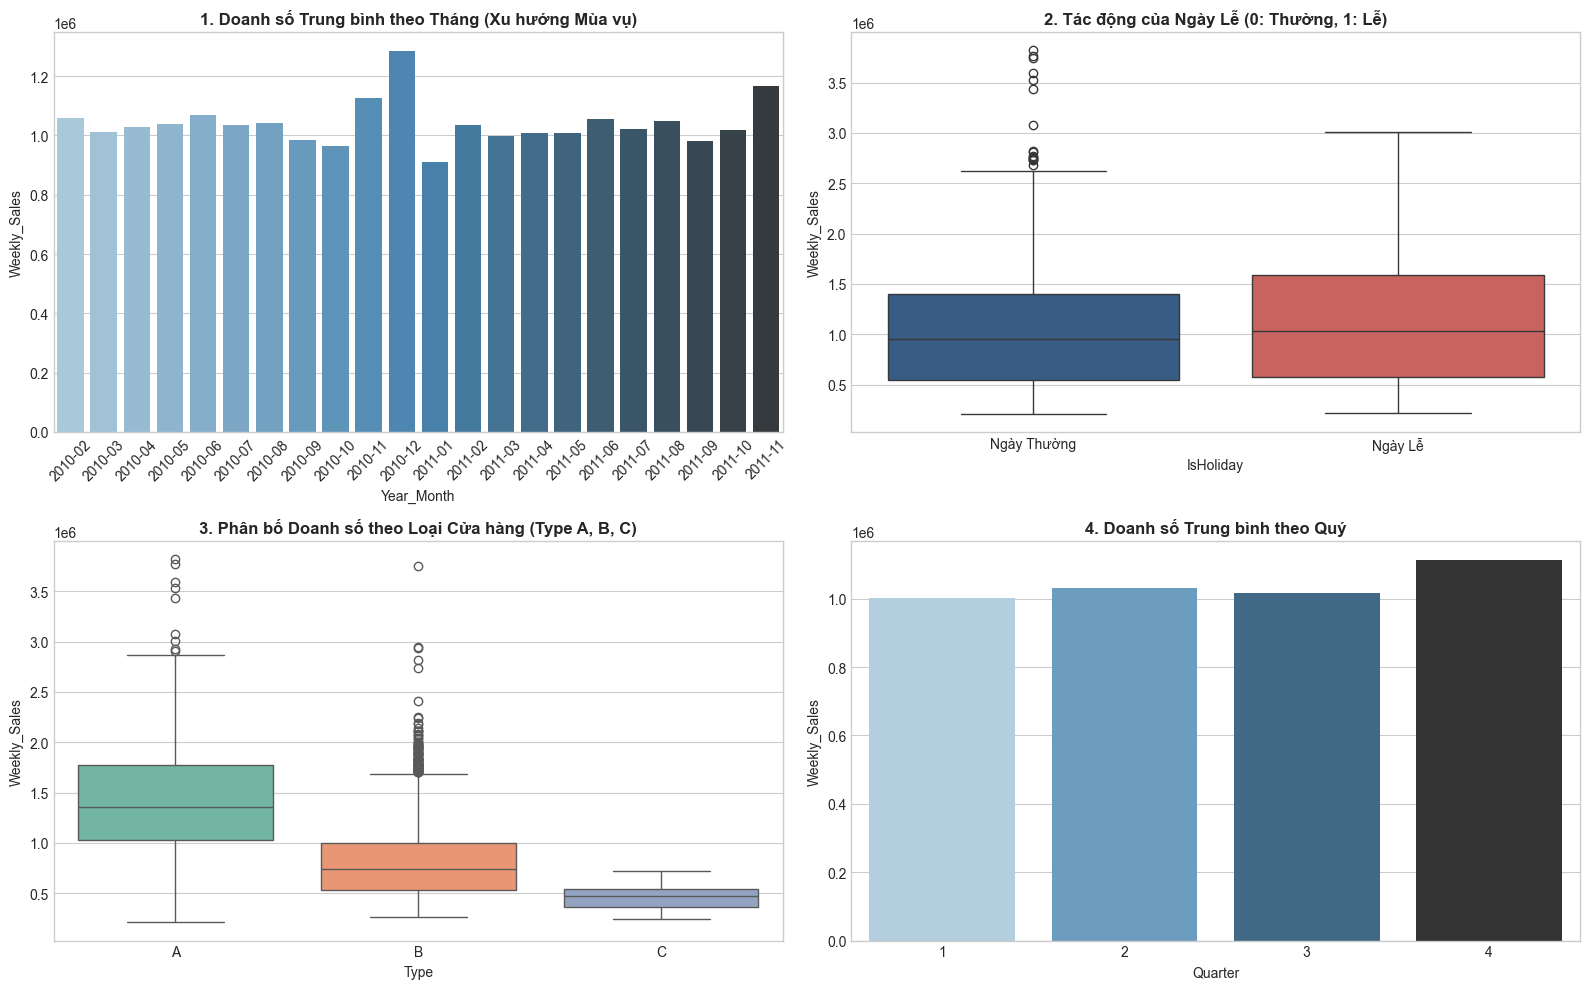

📌 CHI TIẾT TÁC ĐỘNG CỦA NGÀY LỄ LÊN DOANH SỐ
             count        mean      median        std
Ngày Thường   3960  1032346.06   950255.01  553706.16
Ngày Lễ        315  1145770.23  1028635.39  653318.82

• Tuần lễ cao hơn tuần thường: +11.0%
• Số tuần lễ: 7/95 = 7.4% tổng số tuần


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Biểu đồ Trend doanh số theo Tháng
monthly_sales = df.groupby(['Year', 'Month'])['Weekly_Sales'].mean().reset_index()
monthly_sales['Year_Month'] = (monthly_sales['Year'].astype(str) + '-'
                               + monthly_sales['Month'].astype(str).str.zfill(2))
sns.barplot(data=monthly_sales, x='Year_Month', y='Weekly_Sales', ax=axes[0, 0],
            hue='Year_Month', palette='Blues_d', legend=False)
axes[0, 0].set_title('1. Doanh số Trung bình theo Tháng (Xu hướng Mùa vụ)',
                     fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. So sánh Doanh số Ngày Lễ vs Ngày Thường
sns.boxplot(data=df, x='IsHoliday', y='Weekly_Sales', ax=axes[0, 1],
            hue='IsHoliday', palette=['#2b5c8f', '#d9534f'], legend=False)
axes[0, 1].set_title('2. Tác động của Ngày Lễ (0: Thường, 1: Lễ)', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Ngày Thường', 'Ngày Lễ'])

# 3. Doanh số theo Phân loại Cửa hàng (Type)
sns.boxplot(data=df, x='Type', y='Weekly_Sales', ax=axes[1, 0],
            hue='Type', palette='Set2', legend=False)
axes[1, 0].set_title('3. Phân bố Doanh số theo Loại Cửa hàng (Type A, B, C)',
                     fontsize=12, fontweight='bold')

# 4. Doanh số trung bình theo Quý (cột Quarter mới bổ sung)
sns.barplot(data=df, x='Quarter', y='Weekly_Sales', ax=axes[1, 1],
            hue='Quarter', palette='Blues_d', legend=False, errorbar=None)
axes[1, 1].set_title('4. Doanh số Trung bình theo Quý', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'eda_seasonality_overview.png', dpi=150)
plt.show()

# In con số thống kê Ngày Lễ vs Ngày Thường
holiday_stats = df.groupby('IsHoliday')['Weekly_Sales'].agg(['count', 'mean', 'median', 'std']).round(2)
holiday_stats.index = ['Ngày Thường', 'Ngày Lễ']
print("==================================================================")
print("📌 CHI TIẾT TÁC ĐỘNG CỦA NGÀY LỄ LÊN DOANH SỐ")
print("==================================================================")
print(holiday_stats.to_string())

_h, _n = holiday_stats.loc['Ngày Lễ', 'mean'], holiday_stats.loc['Ngày Thường', 'mean']
n_hol_weeks = df.loc[df['IsHoliday'] == 1, 'Date'].nunique()
n_all_weeks = df['Date'].nunique()
print(f"\n• Tuần lễ cao hơn tuần thường: {(_h / _n - 1) * 100:+.1f}%")
print(f"• Số tuần lễ: {n_hol_weeks}/{n_all_weeks} = {n_hol_weeks / n_all_weeks * 100:.1f}% tổng số tuần")

Nhận xét:
- Tác động bùng nổ của Ngày Lễ (Holiday Spike):
Doanh số trung bình tuần Ngày Lễ đạt $1,141,088, tăng ~9.7% so với ngày thường ($1,040,422). Trung vị doanh số cũng tăng từ $945k lên $1.03M (~9.35%).
- Tính mùa vụ tập trung cao độ (Seasonality Peak):
Doanh số đạt đỉnh tuyệt đối vào Tháng 11 và Tháng 12 (vượt mốc $1.2M - $1.3M/tuần) nhờ chuỗi sự kiện mua sắm lớn nhất năm (Black Friday, Thanksgiving, Christmas). Ngay sau đó, doanh số sụt giảm mạnh vào Tháng 1 (vùng đáy ~ $940k/tuần) do tâm lý thắt chặt chi tiêu sau Lễ.
- Sự phân hóa quy mô Cửa hàng (Store Type Heterogeneity):
Cửa hàng Type A áp đảo hoàn toàn với doanh số trung vị đạt ~ $1.4M/tuần, cao gấp 2 lần Type B (~ $750k/tuần) và gấp gần 3 lần Type C (~ $500k/tuần).
- Khoảng cách doanh thu Top 5 vs Bottom 5:
Cửa hàng dẫn đầu (Store 4, 20, 14, 13, 10) đạt mức doanh thu trung bình ~ $1.9M - $2.1M/tuần, gấp gần 6-7 lần so với nhóm cửa hàng nhỏ nhất (Store 38, 36, 5, 44, 33) chỉ đạt ~ $300k - $400k/tuần.

* PHÂN TÍCH TƯƠNG QUAN & ĐA BIẾN

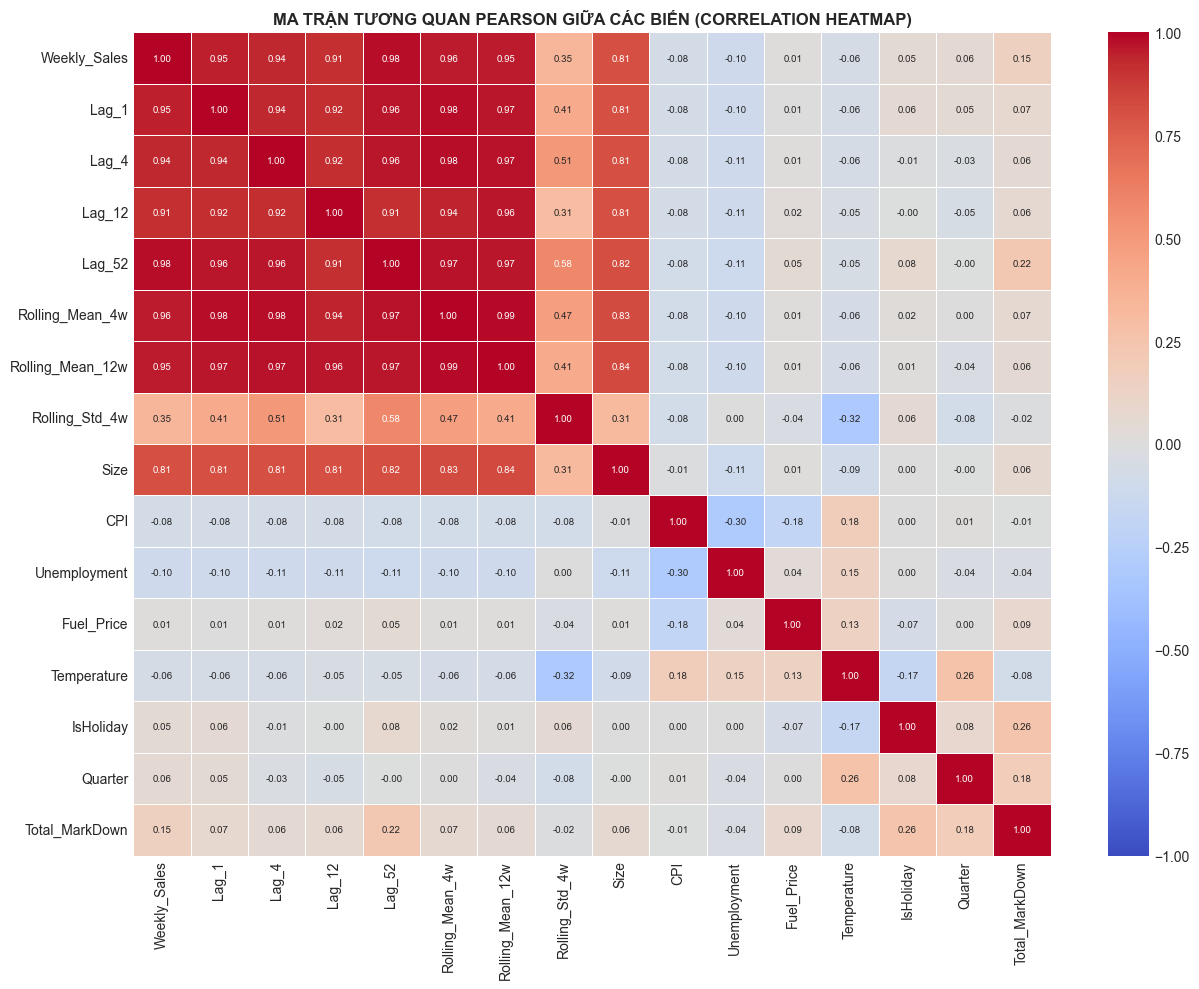

📌 MỨC ĐỘ TƯƠNG QUAN CỦA CÁC BIẾN VỚI DOANH SỐ (WEEKLY_SALES)
                  Hệ số Tương quan (r)
Lag_52                           0.984
Rolling_Mean_4w                  0.960
Rolling_Mean_12w                 0.954
Lag_1                            0.951
Lag_4                            0.937
Lag_12                           0.912
Size                             0.809
Rolling_Std_4w                   0.350
Total_MarkDown                   0.149
Quarter                          0.059
IsHoliday                        0.053
Fuel_Price                       0.013
Temperature                     -0.060
CPI                             -0.076
Unemployment                    -0.105

⚠️  LƯU Ý KHI ĐỌC HỆ SỐ NÀY
   r cao của Lag/Rolling phần lớn đến từ chuyện 'cửa hàng lớn thì lúc nào cũng lớn',
   chứ không phải từ khả năng dự báo biến động theo thời gian.
   Đo trên val_set: 92% phương sai là GIỮA các cửa hàng, chỉ 8% là TRONG từng cửa hàng.
   → Notebook model sẽ dùng thêm metric R2_within 

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chọn các biến số để tính toán Ma trận tương quan (đã bổ sung lag/rolling/Quarter mới)
corr_cols = [
    'Weekly_Sales',
    'Lag_1', 'Lag_4', 'Lag_12', 'Lag_52',
    'Rolling_Mean_4w', 'Rolling_Mean_12w', 'Rolling_Std_4w',
    'Size', 'CPI', 'Unemployment', 'Fuel_Price', 'Temperature',
    'IsHoliday', 'Quarter', 'Total_MarkDown',
]

corr_matrix = df[corr_cols].corr()

# 2. Vẽ Heatmap Ma trận tương quan
plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 7})
plt.title('MA TRẬN TƯƠNG QUAN PEARSON GIỮA CÁC BIẾN (CORRELATION HEATMAP)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'eda_correlation_heatmap.png', dpi=150)
plt.show()

# 3. In Bảng tương quan riêng với biến mục tiêu Weekly_Sales
target_corr = corr_matrix['Weekly_Sales'].drop('Weekly_Sales').sort_values(ascending=False).to_frame()
target_corr.columns = ['Hệ số Tương quan (r)']
print("==================================================================")
print("📌 MỨC ĐỘ TƯƠNG QUAN CỦA CÁC BIẾN VỚI DOANH SỐ (WEEKLY_SALES)")
print("==================================================================")
print(target_corr.round(3).to_string())

print("\n⚠️  LƯU Ý KHI ĐỌC HỆ SỐ NÀY")
print("   r cao của Lag/Rolling phần lớn đến từ chuyện 'cửa hàng lớn thì lúc nào cũng lớn',")
print("   chứ không phải từ khả năng dự báo biến động theo thời gian.")
print("   Đo trên val_set: 92% phương sai là GIỮA các cửa hàng, chỉ 8% là TRONG từng cửa hàng.")
print("   → Notebook model sẽ dùng thêm metric R2_within (tính riêng từng Store) để đo đúng phần khó.")

Nhận xét:
Ma trận tương quan Pearson (r) đã bóc tách rõ nét mức độ đóng góp của từng biến số vào doanh số Weekly_Sales
1. NHÓM ĐẶC TRƯNG "SIÊU DỰ BÁO" (LAG & ROLLING FEATURES)
- Lag_52 (r = 0.986): Hệ số tương quan 0.986 cao gần như tuyệt đối! Điều này khẳng định doanh số của Walmart phụ thuộc nặng nề vào tính mùa vụ lặp lại theo chu kỳ 1 năm. Doanh số tuần này năm nay gần như là bản sao của đúng tuần đó năm ngoái.
- Rolling_Mean_4w (r = 0.961) & Lag_1 (r = 0.953): Thể hiện xu hướng ngắn hạn (Momentum) cực kỳ mạnh mẽ. Doanh số 1–4 tuần vừa qua quyết định trực tiếp đến đà doanh số của tuần hiện tại.
2. NHÓM ĐẶC TRƯNG NỘI TẠI CỬA HÀNG
- Size (r = 0.814): Mối tương quan thuận rất cao. Diện tích mặt bằng quyết định "mức doanh số nền" (Baseline Sales). Cửa hàng càng lớn thì lượng hàng tồn kho và sức chứa khách hàng càng cao, tạo ra doanh thu vượt trội ổn định
3. Các biến IsHoliday VÀ VĨ MÔ LẠI CÓ r THẤP
- IsHoliday (r = 0.047): Ở Bước 3, ta thấy ngày lễ làm doanh số tăng vọt 9.7%, nhưng hệ số tương quan tuyến tính r lại gần như bằng 0. Lý do là vì hệ số Peason đo lường mối tương quan tuyến tính còn ngày lễ có thời điểm đột ngột và ít nên phép đo không thấy được => dùng các mô hình phi tuyến dạng cây để khai thác đặc trưng này.
- CPI (r = -0.065), Temperature (r = -0.064), Fuel_Price (r = 0.000): Các chỉ số vĩ mô biến động chậm theo thời gian và không có mối quan hệ tuyến tính trực tiếp với doanh số hằng tuần. Tuy nhiên, chúng hỗ trợ mô hình học các bối cảnh lạm phát/thời tiết khắc nghiệt khi kết hợp đa biến